In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip
from astropy.time import Time

import FVar

In [2]:
file = "TESS_lightcurves.txt"
df = pd.read_csv(file, sep=r"\s+")
print(df.head())
print(df.columns)

     time_BTJD  Normalised_flux  Normalised_flux_err  centroid_col  \
0  1468.286257         0.999952             0.000031   1841.667805   
1  1468.307091         0.999919             0.000031   1841.666938   
2  1468.327925         1.000002             0.000031   1841.669373   
3  1468.348759         0.999857             0.000031   1841.666608   
4  1468.369593         0.999998             0.000031   1841.666186   

   centroid_row  quality  
0    231.117005        0  
1    231.117060        0  
2    231.115891        0  
3    231.117774        0  
4    231.117744        0  
Index(['time_BTJD', 'Normalised_flux', 'Normalised_flux_err', 'centroid_col',
       'centroid_row', 'quality'],
      dtype='str')


In [3]:
quality_values = sorted(df["quality"].unique())

print("Quality values:", quality_values)

Quality values: [np.int64(0), np.int64(2048)]


Quality = 0
Before 3 sigma clipping = 13825
After 3 sigma clipping  = 11615
FVar = 0.002171045146146645 ± 7.259435898213269e-07



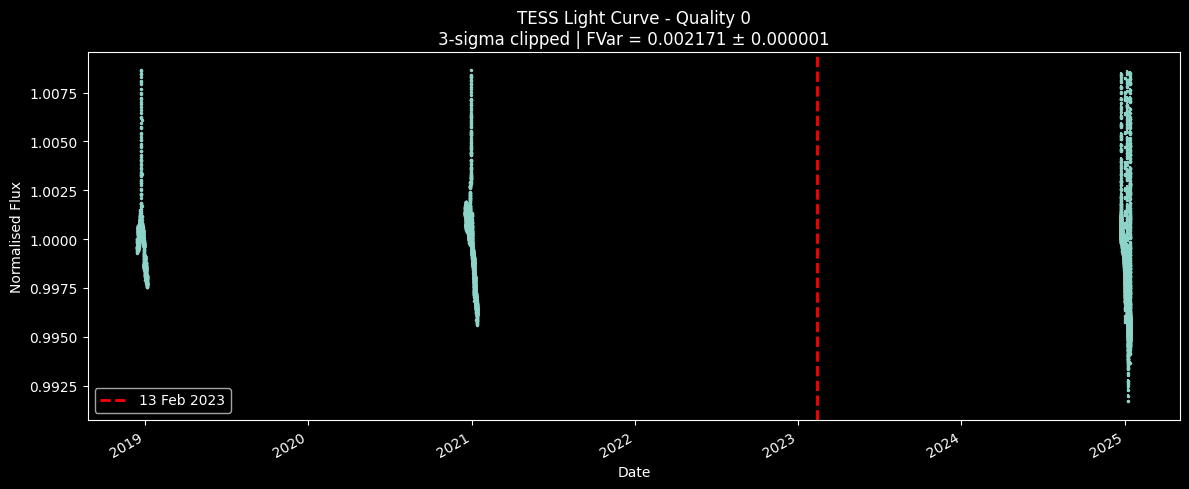

Quality = 2048
Before 3 sigma clipping = 1742
After 3 sigma clipping  = 1474
FVar = 0.38124242746951154 ± 1.6889108218065552e-06



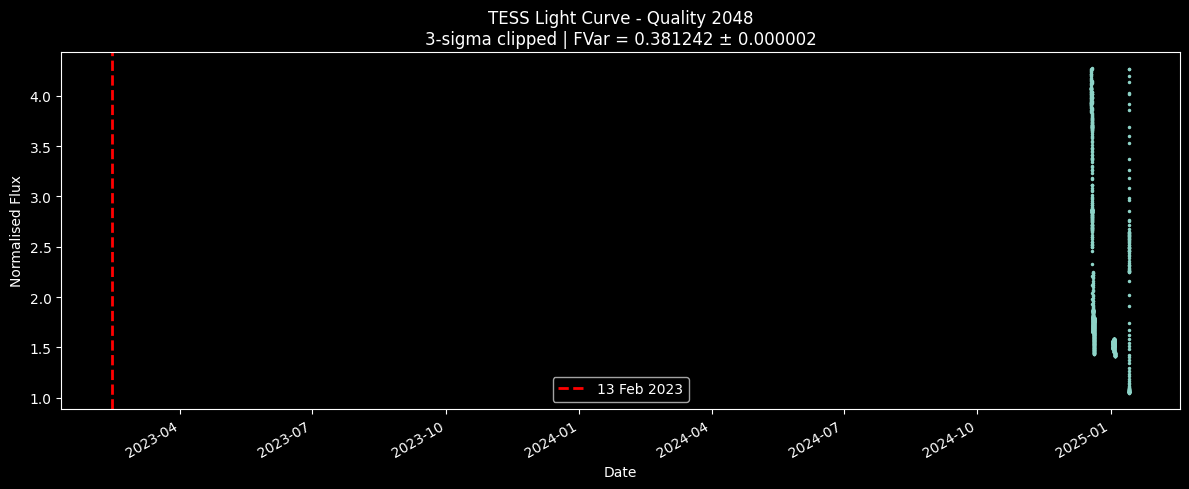

In [4]:
results = []

for q in quality_values:

    # Select this quality
    data_q = df[df["quality"] == q].copy()

    data_q = data_q.dropna(
        subset=[
            "time_BTJD",
            "Normalised_flux",
            "Normalised_flux_err"
        ]
    )

    # -------------------------
    # 3-sigma clipping
    # -------------------------

    clipped_flux = sigma_clip(
        data_q["Normalised_flux"],
        sigma=3,
        maxiters=5
    )

    clean_q = data_q.loc[~clipped_flux.mask].copy()

    # -------------------------
    # Convert BTJD to date/time
    # -------------------------

    clean_q["datetime"] = Time(
        clean_q["time_BTJD"].to_numpy() + 2457000,
        format="jd"
    ).to_datetime()

    # -------------------------
    # FVar calculation
    # -------------------------

    flux = clean_q["Normalised_flux"].to_numpy()
    flux_error = clean_q["Normalised_flux_err"].to_numpy()

    fvar = FVar.Fractional_variability(
        flux,
        flux_error
    )

    fvar_error = FVar.Error_in_fractional_variability(
        flux,
        flux_error
    )

    print(f"Quality = {q}")
    print(f"Before 3 sigma clipping = {len(data_q)}")
    print(f"After 3 sigma clipping  = {len(clean_q)}")
    print(f"FVar = {fvar} ± {fvar_error}")
    print()

    # -------------------------
    # Light curve plot
    # -------------------------

    plt.figure(figsize=(12, 5))

    plt.errorbar(
        clean_q["datetime"],
        clean_q["Normalised_flux"],
        yerr=clean_q["Normalised_flux_err"],
        fmt=".",
        markersize=3
    )

    plt.axvline(
        pd.Timestamp("2023-02-13"),
        color="red",
        linestyle="--",
        linewidth=2,
        label="13 Feb 2023"
    )
    plt.xlabel("Date")
    plt.ylabel("Normalised Flux")

    plt.title(
        f"TESS Light Curve - Quality {q}\n"
        f"3-sigma clipped | FVar = {fvar:.6f} ± {fvar_error:.6f}"
    )

    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # Save values
    results.append({
        "quality": q,
        "FVar": fvar,
        "FVar_error": fvar_error,
        "N_before": len(data_q),
        "N_after": len(clean_q)
    })